# Processing proteomics data of Pancreatic Ductal Adenocarcinoma

## Imports

In [1]:
#Import libraries
import pandas as pd
import numpy as np
from networkx import out_degree_centrality
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from random import sample
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import sklearn
import scanpy as sc


## File paths

In [10]:
#File paths
proteome_file = "../../../data/raw/proteome/proteomics_PDAC.txt"
proteome_norm_file = "../../../data/raw/proteome/proteomics_Normal.txt"
hgnc_path = "../../../data/raw/HGNC_genes/hgnc_complete_set.txt"
mapping_dir = "../../../data/processed/genelist/"
output_dataset_dir = "../../../data/processed/proteome/"
output_dir = "../../../results/"
final_common_genes = "../../../data/processed/genelist/common_genes.txt"
# RNA processed files
gtex_file = "../../../data/processed/gtex_final.csv"
tcga_file = "../../../data/processed/tcga_final.csv"

## Helper functions


In [3]:
# Step 1: load proteome data

def load_proteome_data(proteome_file):
    """
    Load proteome data from a tab-separated file.
    Assumes the first column is gene identifiers and sets it as the index.
    """
    proteome_df = pd.read_csv(proteome_file, sep="\t", index_col=0)
    proteome_df.index.name = "gene_id"
    print(f"Proteome data shape: {proteome_df.shape}")
    return proteome_df

# Step 2: Check for NAs per gene
def check_na_per_gene(proteome_df):
    """
    Check the fraction of NAs per gene in the proteome dataframe.
    """
    na_fraction = proteome_df.isna().mean(axis=1)
    print(f"Number of genes with NAs: {na_fraction[na_fraction > 0].count()} out of {len(na_fraction)}")
    print(f"Average NA fraction per gene: {na_fraction.mean():.4f}")

    print(f"number of Nas in the dataframe: {proteome_df.isna().sum().sum()} of {proteome_df.shape[0]*proteome_df.shape[1]} total values")
    print(f"Fraction of NAs in the dataframe: {proteome_df.isna().sum().sum()/(proteome_df.shape[0]*proteome_df.shape[1]):.4f}")
    
    return na_fraction

# histogram of missing value distribution

def histogram_na_distribution(na_fraction):
    """
    Create a histogram of the NA fractions per gene.
    """
    plt.hist(na_fraction, bins=50, color='skyblue', edgecolor='black')
    plt.title('Histogram of NA Fractions per Gene')
    plt.xlabel('Fraction of NAs')
    plt.ylabel('Number of Genes')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

# Step 3: Convert 0s to NAs
def convert_from_na_to_zero(proteome_df):
    df_zero = proteome_df.fillna(0)
    return df_zero

# Step 4: Remove genes with more than 50% NAs and convert 0s to NAs
def remove_genes_with_high_na(proteome_df, na_fraction, threshold=0.5):
    """
    Remove genes with a fraction of NAs greater than the specified threshold.
    """
    filtered_proteome_df = proteome_df[na_fraction <= threshold]

    print(f"Number of genes removed due to high NA fraction (> {threshold*100}%): {len(proteome_df) - len(filtered_proteome_df)}")
    print(f"Remaining genes after filtering: {len(filtered_proteome_df)}")
    return filtered_proteome_df

# Step 5: KNN imputation
def impute_missing_values(proteome_df, n_neighbors=5):
    imputer = KNNImputer(n_neighbors=n_neighbors)
    imputed_array = imputer.fit_transform(proteome_df)

    imputed_df = pd.DataFrame(imputed_array,
                            index=proteome_df.index,
                            columns=proteome_df.columns)
    
    return imputed_df


# Step 6: Symbol -> ENSG mapping function
def map_symbols_to_ensg(proteome_df, hgnc_path, deduplicate='first', agg='mean'):
    """
    Map index gene symbols to Ensembl gene IDs using HGNC.

    Parameters:
    - proteome_df: DataFrame with gene symbols as index
    - hgnc_path: path to HGNC complete set TSV
    - deduplicate: how to resolve duplicate ENSG IDs after mapping:
        'first' (keep first) or 'agg' (aggregate by agg function)
    - agg: aggregation function name when deduplicate='agg' (e.g., 'mean','median')
    """
    hgnc_map = pd.read_csv(hgnc_path, sep='\t', low_memory=False)
    symbol_to_ensg = dict(zip(hgnc_map['symbol'], hgnc_map['ensembl_gene_id']))

    df = proteome_df.copy()
    df['gene_id'] = df.index.map(symbol_to_ensg)
    # remove genes without mapping, set ENSG as index, sort
    df = df.dropna(subset=['gene_id']).set_index('gene_id').sort_index()

    # handle duplicate ENSG IDs if present
    if df.index.duplicated().any():
        dup_count = df.index.duplicated().sum()
        print(f"Found {dup_count} duplicate ENSG rows; resolving with '{deduplicate}'.")
        if deduplicate == 'first':
            df = df[~df.index.duplicated(keep='first')]
        elif deduplicate == 'agg':
            df = df.groupby(level=0).agg(agg)
        else:
            raise ValueError("deduplicate must be 'first' or 'agg'")

    print(f"Proteome data shape after ENSG mapping: {df.shape}")
    return df

# Keep only genes present in both proteomes
def intersect_proteome_genes(proteome_df1, proteome_df2):
    """
    Keep only genes present in both proteome dataframes.
    """
    common_genes = proteome_df1.index.intersection(proteome_df2.index)
    common_genes = common_genes.sort_values()


    print(f"Number of common genes between datasets: {len(common_genes)}")

    proteome_df1_filt = proteome_df1.loc[common_genes]
    proteome_df2_filt = proteome_df2.loc[common_genes]

    #save gene list
    with open(mapping_dir + "proteome_common_genes.txt", "w") as f:
        for gene in common_genes:
            f.write(str(gene) + "\n")


    return proteome_df1_filt, proteome_df2_filt

# Step 7: Log2 transformation (0 -> NaNs)
def log2_transform(proteome_df):
    """
    Apply log2 transformation to the proteome data.
    Replace zeros with NaN before transformation.
    """
    print("Applying log2 transformation...")
    print(f"Highest value before log2: {proteome_df.max().max()}")
    df = np.log2(proteome_df)
    print(f"Highest value after log2: {df.max().max()}")
    
    return df


# Z-score normalization
def zscore_normalization(proteome_df):
    """
    Apply Z-score normalization to the proteome data.
    """
    print("Applying Z-score normalization...")
    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(proteome_df.T).T  # Transpose to scale features (genes)
    
    scaled_df = pd.DataFrame(scaled_array,
                             index=proteome_df.index,
                             columns=proteome_df.columns)

    
    print("Z-score normalization complete.")
    return scaled_df


In [4]:
# PCA functions

import matplotlib.pyplot as plt

def pca_normal_tumor(df_normal, df_tumor):
    """Return pcs, variance ratio, and labels for Normal vs Tumor PCA.
    Ensures only numeric sample columns are used and handles NaNs.
    """
    # Keep only numeric columns (samples) and align genes (index)
    df_normal_num = df_normal.select_dtypes(include=[np.number])
    df_tumor_num = df_tumor.select_dtypes(include=[np.number])

    # Match genes
    common = df_normal_num.index.intersection(df_tumor_num.index)
    if len(common) == 0:
        raise ValueError("No common genes between the provided datasets.")

    norm = df_normal_num.loc[common]
    tum = df_tumor_num.loc[common]

    # Combine (genes x samples) and fill any NaNs with 0 for PCA
    combined = pd.concat([norm, tum], axis=1)
    combined = combined.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    labels = (["Normal"] * norm.shape[1]) + (["Tumor"] * tum.shape[1])

    # Sanity check: ensure we have numeric matrix
    if combined.size == 0 or combined.select_dtypes(include=[np.number]).shape[1] == 0:
        raise ValueError("No numeric columns available for PCA after filtering.")

    # PCA expects samples x features
    X = combined.T
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)
    vr = pca.explained_variance_ratio_

    return pcs, vr, labels

def plot_pca_panel(
    raw_norm, raw_tum,
    clean_norm, clean_tum,
    imp_norm, imp_tum,
    log_norm, log_tum,
    z_norm, z_tum
):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    datasets = [
        ("Raw Proteome", raw_norm, raw_tum),
        ("Cleaned Proteome", clean_norm, clean_tum),
        ("Imputed Proteome", imp_norm, imp_tum),
        ("Log2 Proteome", log_norm, log_tum),
        ("Z-scored Proteome", z_norm, z_tum),
        ("", None, None)  # empty placeholder for layout
    ]

    for ax, (title, df_norm, df_tum) in zip(axes, datasets):
        if title == "":
            ax.axis("off")
            continue

        pcs, vr, labels = pca_normal_tumor(df_norm, df_tum)
        for lab, color in [("Normal", "blue"), ("Tumor", "orange")]:
            mask = [l == lab for l in labels]
            ax.scatter(pcs[mask, 0], pcs[mask, 1], s=18, alpha=0.7, label=lab)

        ax.set_title(f"{title}\nPC1={vr[0]*100:.1f}%, PC2={vr[1]*100:.1f}%")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# PCA with 4 datasets in one plot

def pca_four_datasets(
    gtex_df, tcga_df,
    proteome_df, proteome_norm_df
):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Pre-filter numeric columns for each dataset explicitly
    gtex_df_num = gtex_df.select_dtypes(include=[np.number])
    tcga_df_num = tcga_df.select_dtypes(include=[np.number])
    proteome_df_num = proteome_df.select_dtypes(include=[np.number])
    proteome_norm_df_num = proteome_norm_df.select_dtypes(include=[np.number])

    datasets = [
        ("GTEx RNA-seq", gtex_df_num, "green"),
        ("TCGA RNA-seq", tcga_df_num, "red"),
        ("Proteome Tumor", proteome_df_num, "orange"),
        ("Proteome Normal", proteome_norm_df_num, "blue")
    ]

    for title, df, color in datasets:
        pcs, vr, labels = pca_normal_tumor(df, df)
        ax.scatter(pcs[:, 0], pcs[:, 1], s=18, alpha=0.7, label=title, color=color)

    ax.set_title("PCA of RNA-seq and Proteome Datasets")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Main pipeline: 

### Load and clean: 

In [11]:
# Load proteome data
proteome_tumor_load = load_proteome_data(proteome_file)
proteome_norm_load = load_proteome_data(proteome_norm_file)

Proteome data shape: (11662, 140)
Proteome data shape: (11662, 75)


#### Check for the presence of NaN

Number of genes with NAs: 5913 out of 11662
Average NA fraction per gene: 0.2483
number of Nas in the dataframe: 217164 of 874650 total values
Fraction of NAs in the dataframe: 0.2483


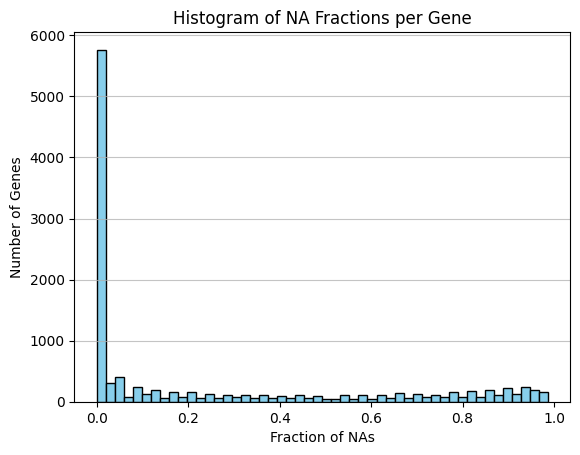

Number of genes with NAs: 5895 out of 11662
Average NA fraction per gene: 0.2463
number of Nas in the dataframe: 402161 of 1632680 total values
Fraction of NAs in the dataframe: 0.2463


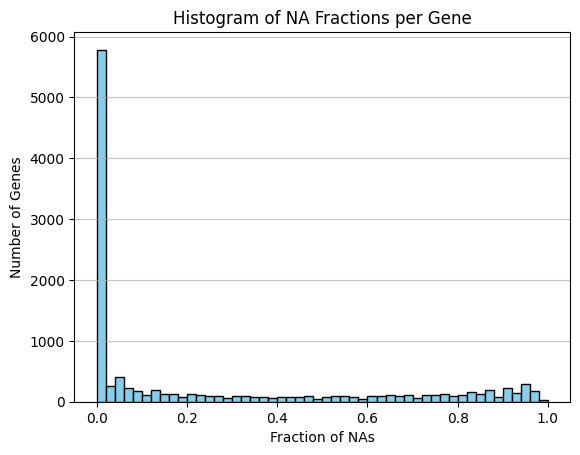

In [12]:
# Na check
na_norm_fraction = check_na_per_gene(proteome_norm_load)
histogram_na_distribution(na_norm_fraction)
na_tumor_fraction = check_na_per_gene(proteome_tumor_load)
histogram_na_distribution(na_tumor_fraction)

Number of genes removed due to high NA fraction (> 50.0%): 2911
Remaining genes after filtering: 8751


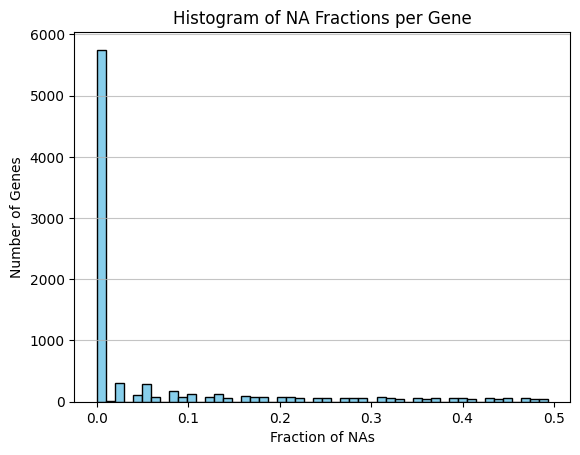

Number of genes removed due to high NA fraction (> 50.0%): 2892
Remaining genes after filtering: 8770


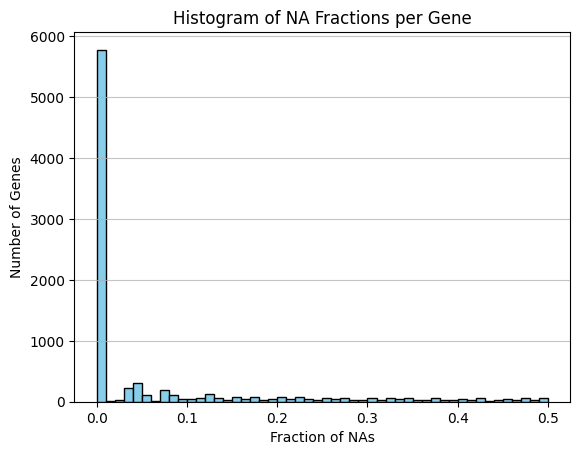

In [13]:
# Clean datasets

proteome_norm_clean = remove_genes_with_high_na(proteome_norm_load, na_norm_fraction, threshold=0.5)
histogram_na_distribution(proteome_norm_clean.isna().mean(axis=1))
proteome_tumor_clean = remove_genes_with_high_na(proteome_tumor_load, na_tumor_fraction, threshold=0.5)
histogram_na_distribution(proteome_tumor_clean.isna().mean(axis=1))

### Imputering av NaN-verdier (Avhengig av GPU)

In [14]:
proteome_norm_imputed = impute_missing_values(proteome_norm_clean, n_neighbors=50)
proteome_tumor_imputed = impute_missing_values(proteome_tumor_clean, n_neighbors=50)

In [18]:
# step 4: Gene symbol mapping to ENSG mapping

proteome_norm_df = map_symbols_to_ensg(proteome_norm_imputed, hgnc_path, deduplicate='first')
proteome_norm_df.head()
proteome_tumor_df = map_symbols_to_ensg(proteome_tumor_imputed, hgnc_path, deduplicate='first')
proteome_tumor_df.head()

Proteome data shape after ENSG mapping: (8511, 75)
Proteome data shape after ENSG mapping: (8529, 140)


,C3L-03394,C3N-03428,C3L-02112,C3N-01719,C3N-03670,C3N-02998,C3N-03211,C3L-01052,C3N-00512,C3N-02295,...,C3L-01031,C3N-01167,C3L-01971,C3L-02604,C3L-00277,C3L-01328,C3L-03639,C3N-04282,C3L-04072,C3L-02613
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,23.044235,20.738850,23.138016,22.392748,22.680326,21.696456,22.316463,22.998737,22.329486,21.706846,...,23.082915,22.347540,22.668808,21.787641,22.593028,22.941109,22.799031,23.009546,22.701312,21.898757
ENSG00000000419,25.230442,25.009547,25.100767,25.222695,25.188440,24.945874,25.091893,24.433849,25.063079,24.970114,...,25.346549,25.544385,24.952821,25.131010,25.015918,24.819754,25.121696,24.912156,25.391117,25.238743
ENSG00000000457,22.794596,22.819442,22.715365,22.662854,22.378293,22.851156,22.939272,22.918712,22.798401,22.863384,...,22.875133,22.755710,22.619512,22.920397,23.333429,22.545766,22.605970,22.622372,22.767225,22.215004
ENSG00000000938,22.106314,21.892640,21.961711,22.641920,22.230623,22.434518,21.988904,22.114951,21.497737,21.233467,...,21.433818,20.994880,21.775168,22.338256,21.794484,22.340958,22.962403,20.866173,22.164020,22.629552
ENSG00000000971,29.680875,29.011177,29.682198,29.882874,29.452377,30.115916,29.008951,29.505553,29.726909,29.913884,...,28.997209,28.940486,29.082511,28.972164,30.578357,29.514255,29.565393,29.602160,28.215523,29.083666


In [19]:
# Harmonize datasets to common genes
proteome_norm_df, proteome_tumor_df = intersect_proteome_genes(proteome_norm_df, proteome_tumor_df)

Number of common genes between datasets: 8409


In [20]:
# Harmonize datasets to common genes
proteome_norm_df, proteome_tumor_df = intersect_proteome_genes(proteome_norm_df, proteome_tumor_df)


# Harmonize datasets with common genes to the final common gene list
final_common_genes_list = pd.read_csv(final_common_genes, sep="\t", header=None)[0].tolist()
proteome_norm_df = proteome_norm_df.loc[final_common_genes_list]
proteome_tumor_df = proteome_tumor_df.loc[final_common_genes_list]

# datashapes
print("Proteome Normal Data Shape:", proteome_norm_df.shape)
print("Proteome Tumor Data Shape:", proteome_tumor_df.shape)

Number of common genes between datasets: 8409
Proteome Normal Data Shape: (8278, 75)
Proteome Tumor Data Shape: (8278, 140)


In [21]:
proteome_norm_log = log2_transform(proteome_norm_df)
proteome_tumor_log = log2_transform(proteome_tumor_df)

Applying log2 transformation...
Highest value before log2: 35.4760826533677
Highest value after log2: 5.148774807779556
Applying log2 transformation...
Highest value before log2: 36.0412523353886
Highest value after log2: 5.171577236634393


In [22]:
# Z-score normalization
proteome_norm_Z = zscore_normalization(proteome_norm_log)
proteome_norm_Z.head()
proteome_tumor_Z = zscore_normalization(proteome_tumor_log)
proteome_tumor_Z.head()

Applying Z-score normalization...
Z-score normalization complete.
Applying Z-score normalization...
Z-score normalization complete.


,C3L-03394,C3N-03428,C3L-02112,C3N-01719,C3N-03670,C3N-02998,C3N-03211,C3L-01052,C3N-00512,C3N-02295,...,C3L-01031,C3N-01167,C3L-01971,C3L-02604,C3L-00277,C3L-01328,C3L-03639,C3N-04282,C3L-04072,C3L-02613
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000187535,1.320767,0.443384,0.761875,-0.622593,0.837636,0.909701,-0.503607,2.045281,0.349823,-1.225987,...,-0.936174,-0.705294,1.157482,-1.836672,-0.478402,-0.895905,-2.722197,1.095443,-1.306971,-0.394930
ENSG00000227057,-0.103288,1.123776,-1.577039,0.439141,0.143640,-0.355395,-0.369210,-1.856710,-0.188375,0.130020,...,-0.105945,0.589959,-0.284050,1.261714,0.344497,1.806905,0.190836,1.282124,1.494411,2.634390
ENSG00000106804,0.492095,-0.349806,-0.301023,1.335783,0.415114,1.557920,-1.031221,-0.039270,0.614569,1.502085,...,-1.289833,-1.325865,-0.185395,0.555574,1.633047,0.726578,1.363029,0.571821,-3.500007,0.673955
ENSG00000183011,-0.067869,0.461528,-1.046124,0.808035,-0.200263,-1.858175,1.545329,-4.254903,2.717495,0.053574,...,-0.038952,-0.533665,-1.197482,2.192493,-0.132798,0.045335,-0.290850,-0.071068,-1.254127,1.163077
ENSG00000166557,-0.182574,-0.674306,-1.320943,1.141934,-0.296231,-0.985365,0.466743,-0.281915,-0.562086,-0.005749,...,0.098657,0.880010,0.001747,0.321635,-0.810994,0.716710,-0.142520,1.035264,0.611537,1.138885


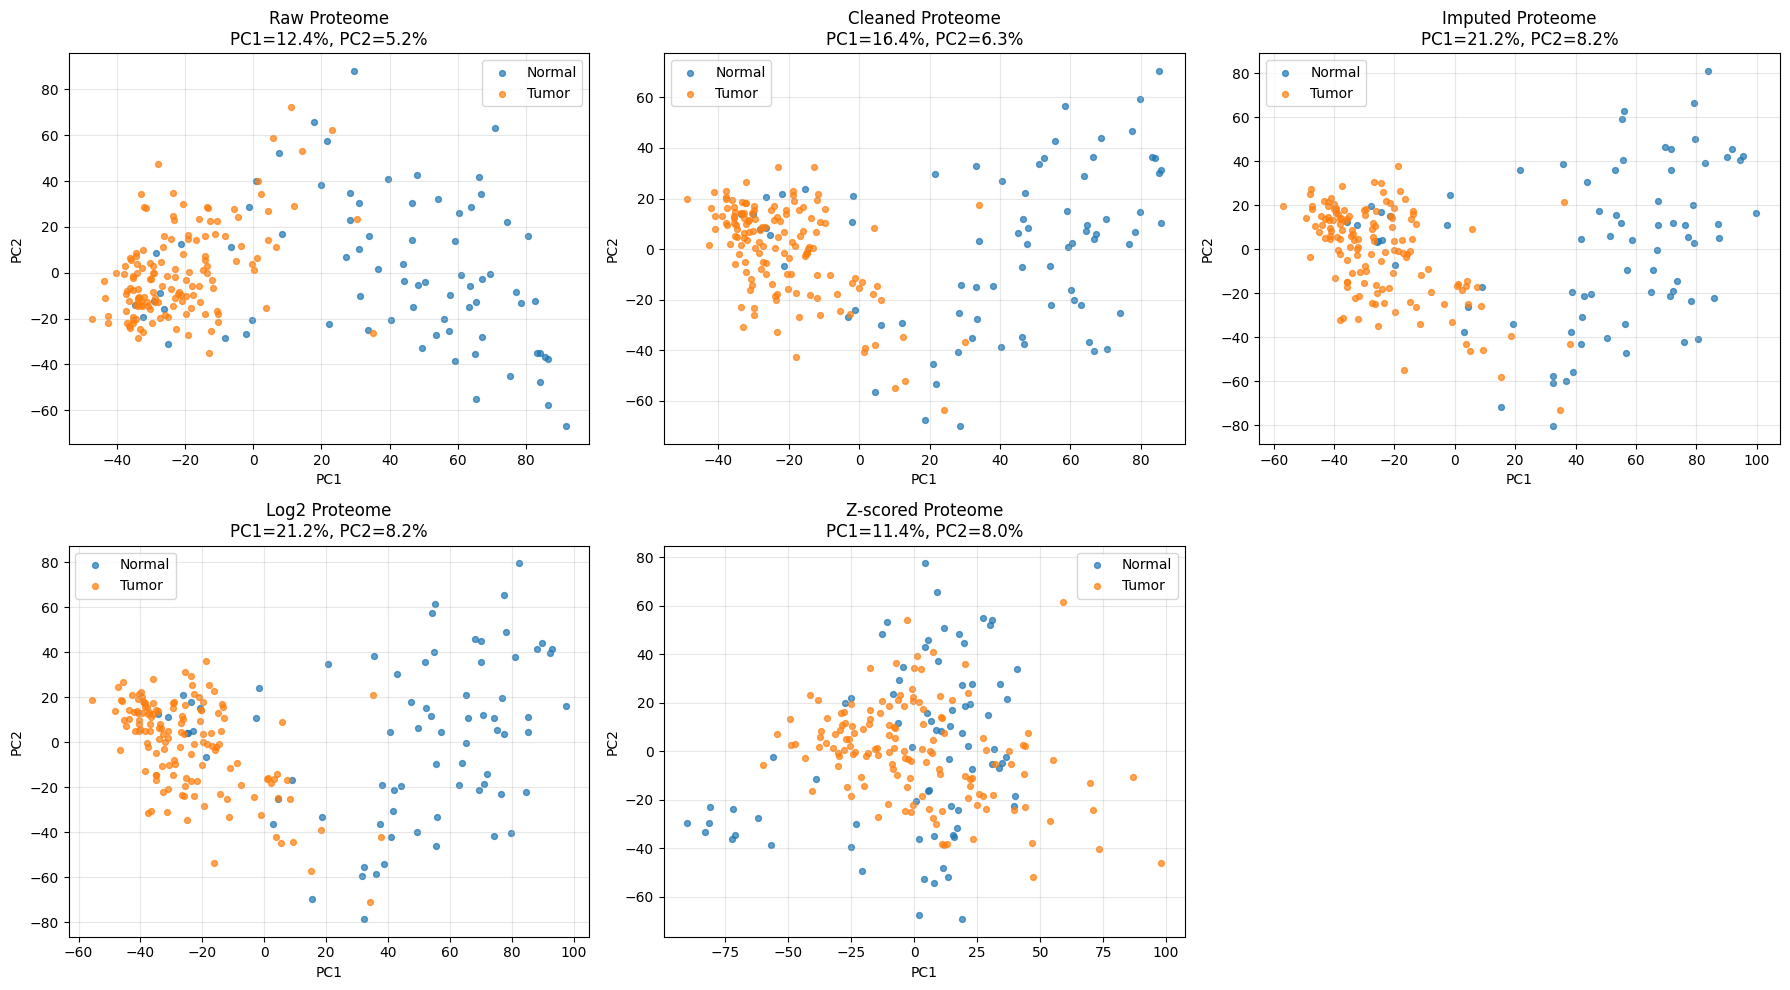

In [23]:
# Plot pca for each processing step
zero_norm_plot = convert_from_na_to_zero(proteome_norm_load)
zero_clean_norm_plot = convert_from_na_to_zero(proteome_norm_clean)
zero_tumor_plot = convert_from_na_to_zero(proteome_tumor_load)
zero_clean_tumor_plot = convert_from_na_to_zero(proteome_tumor_clean)


plot_pca_panel(
    zero_norm_plot, zero_tumor_plot,     # raw
    zero_clean_norm_plot, zero_clean_tumor_plot,   # cleaned
    proteome_norm_imputed, proteome_tumor_imputed, # imputed
    proteome_norm_log, proteome_tumor_log,       # log2
    proteome_norm_Z, proteome_tumor_Z            # Z-score
)

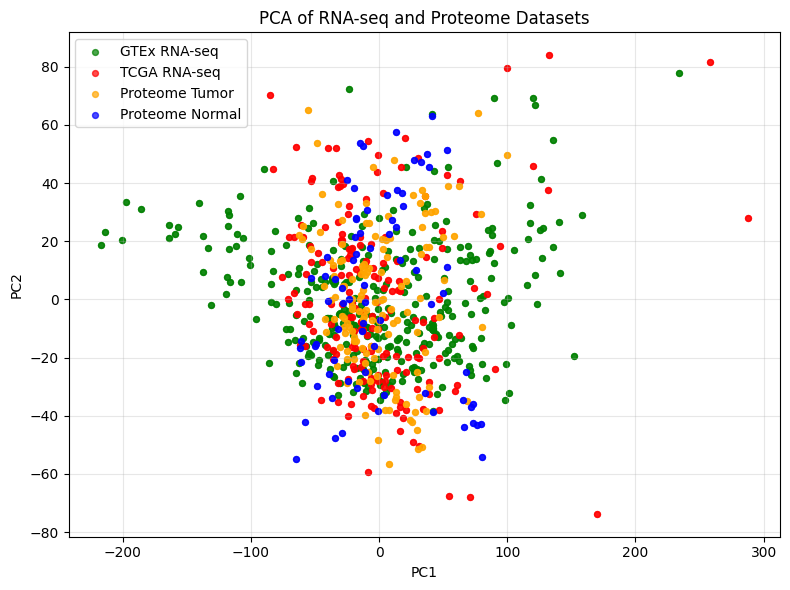

In [24]:
# pca of processed RNA seq and proteome

gtex_df = pd.read_csv(gtex_file, index_col=0)
tcga_df = pd.read_csv(tcga_file, index_col=0)


pca_four_datasets(
    gtex_df, tcga_df,
    proteome_tumor_Z, proteome_norm_Z
)

## Save section

In [28]:
# Save final proteome files
proteome_norm_Z.index = proteome_norm_Z.index.astype(str)
proteome_tumor_Z.index = proteome_tumor_Z.index.astype(str)

# Option 1: keep index as a column
proteome_norm_Z.reset_index().to_csv(output_dataset_dir + "proteome_healthy.txt", sep="\t", header=False, index=False)
print("Saved:", output_dataset_dir + "proteome_healthy.txt")
proteome_tumor_Z.reset_index().to_csv(output_dataset_dir + "proteome_cancer.txt", sep="\t", header=False, index=False)
print("Saved:", output_dataset_dir + "proteome_cancer.txt")

Saved: ../../../data/processed/proteome/proteome_healthy.txt
Saved: ../../../data/processed/proteome/proteome_cancer.txt
